## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


 ## Load Dataset

In [4]:
df = pd.read_excel("Online-Store-Orders.xlsx")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Dataset Overview


In [5]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus   

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [7]:
df.describe(include="all")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,NaN,C38840,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


##  Missing Values Visualization

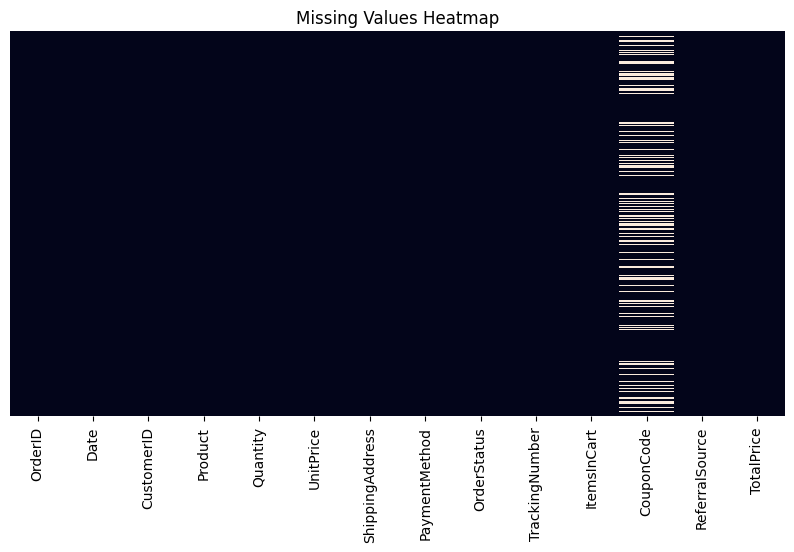

In [8]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

## Missing Values Handling

In [9]:
df["CouponCode"] = df["CouponCode"].fillna("No_Coupon")

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


## Convert Date Column

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date Converted Successfully")

Date Converted Successfully


##  Feature Engineering
#### Feature 1: Order Month
#### Feature 2: Order Year
#### Feature 3: Average Item Cost
#### Feature 4: Discount Applied

In [11]:
df["OrderMonth"] = df["Date"].dt.month

df["OrderYear"] = df["Date"].dt.year

df["AvgItemCost"] = df["TotalPrice"] / df["Quantity"]

df["DiscountApplied"] = np.where(
    df["CouponCode"] == "No_Coupon",
    0,
    1
)

print("New Features Added Successfully")

df.head()

New Features Added Successfully


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,OrderYear,AvgItemCost,DiscountApplied
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023,570.62,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024,151.35,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024,550.68,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023,273.19,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025,626.01,1


## Outlier Detection Using IQR

In [12]:
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower_bound)
    |
    (df["TotalPrice"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 8


## Outliers Before Treatment

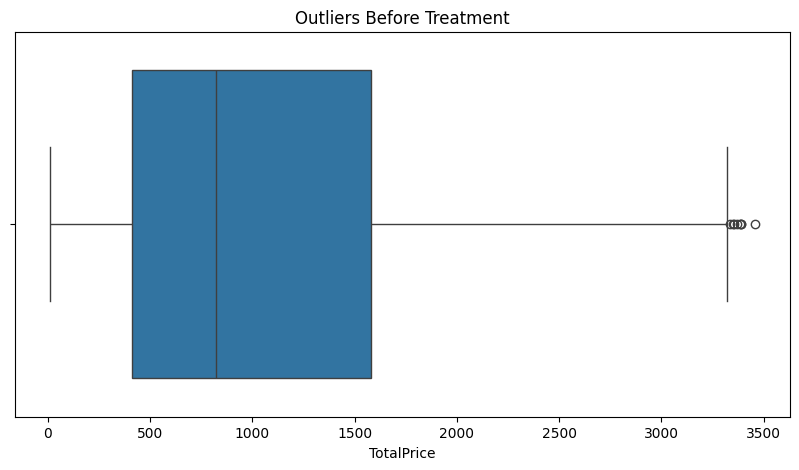

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["TotalPrice"]
)

plt.title("Outliers Before Treatment")

plt.show()

## Outlier Treatment

In [15]:
df["TotalPrice"] = np.where(
    df["TotalPrice"] > upper_bound,
    upper_bound,
    df["TotalPrice"]
)

df["TotalPrice"] = np.where(
    df["TotalPrice"] < lower_bound,
    lower_bound,
    df["TotalPrice"]
)

print("Outliers Treated Successfully")

Outliers Treated Successfully


## Outliers After Treatment

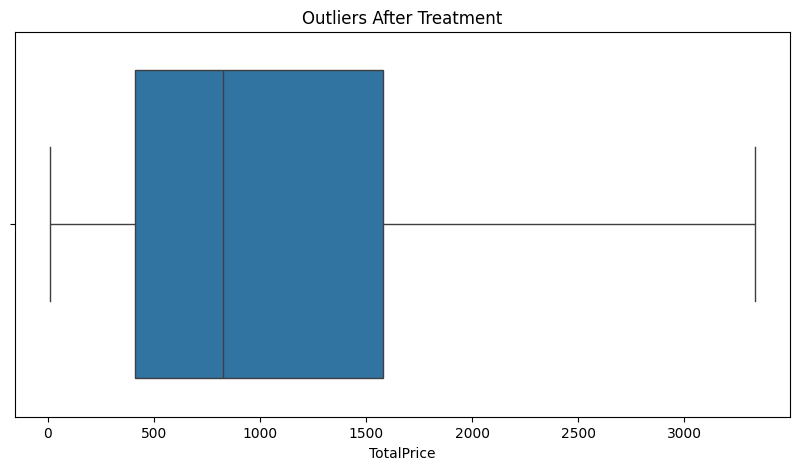

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["TotalPrice"]
)

plt.title("Outliers After Treatment")

plt.show()

## Z-Score Analysis

In [17]:
z_scores = np.abs(
    zscore(df["TotalPrice"])
)

z_outliers = df[
    z_scores > 3
]

print("Z-Score Outliers:", len(z_outliers))

Z-Score Outliers: 0


## Correlation Heatmap

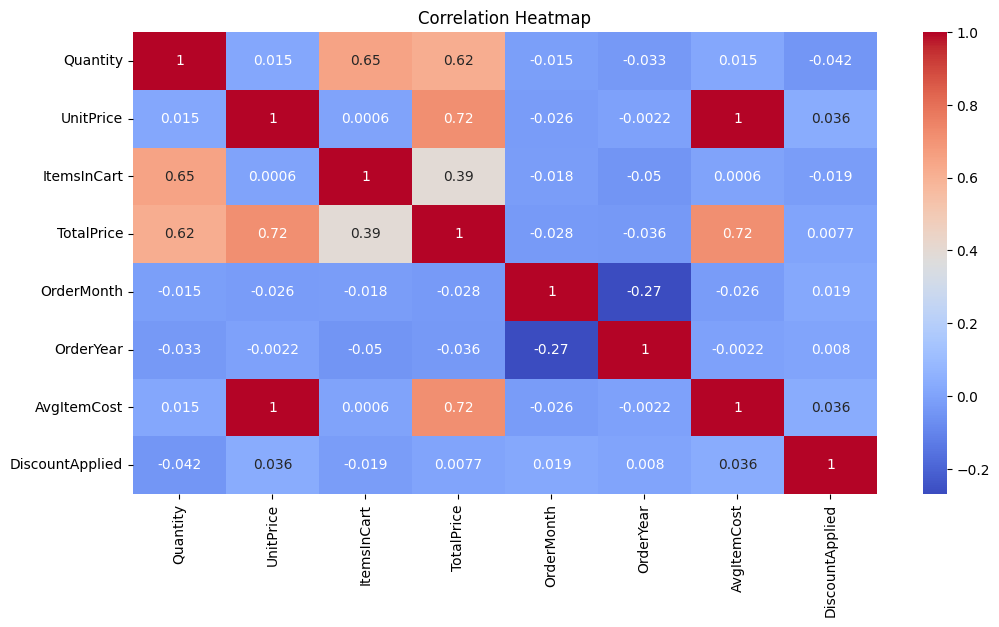

In [19]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Monthly Sales Analysis

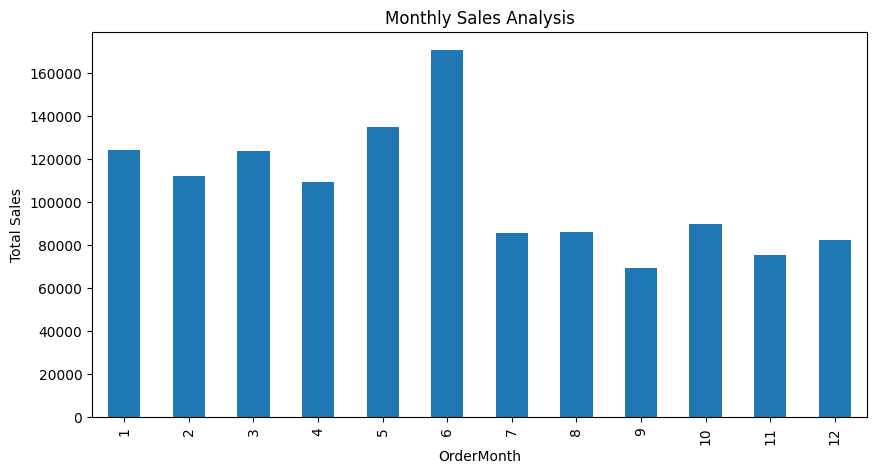

In [20]:
monthly_sales = df.groupby(
    "OrderMonth"
)["TotalPrice"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="bar"
)

plt.title("Monthly Sales Analysis")

plt.ylabel("Total Sales")

plt.show()

## Payment Method Analysis

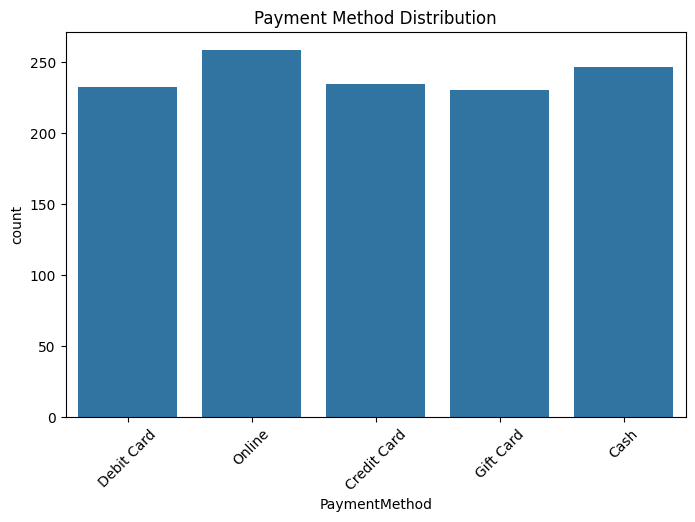

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="PaymentMethod",
    data=df
)

plt.title("Payment Method Distribution")

plt.xticks(rotation=45)

plt.show()

## Order Status Analysis

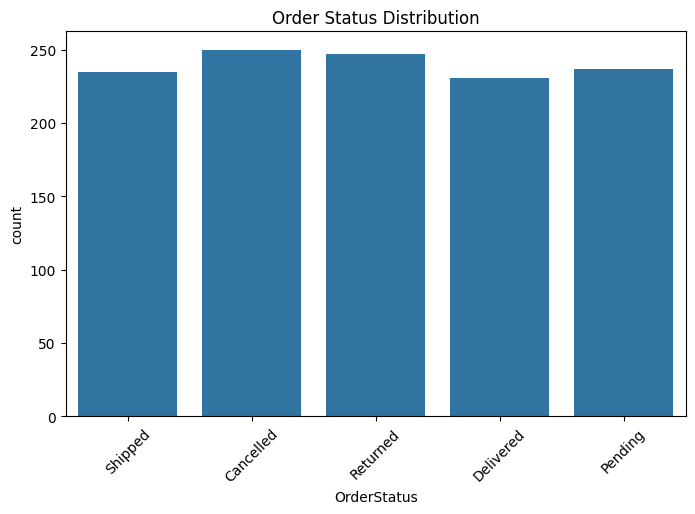

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="OrderStatus",
    data=df
)

plt.title("Order Status Distribution")

plt.xticks(rotation=45)

plt.show()

## Top Selling Products

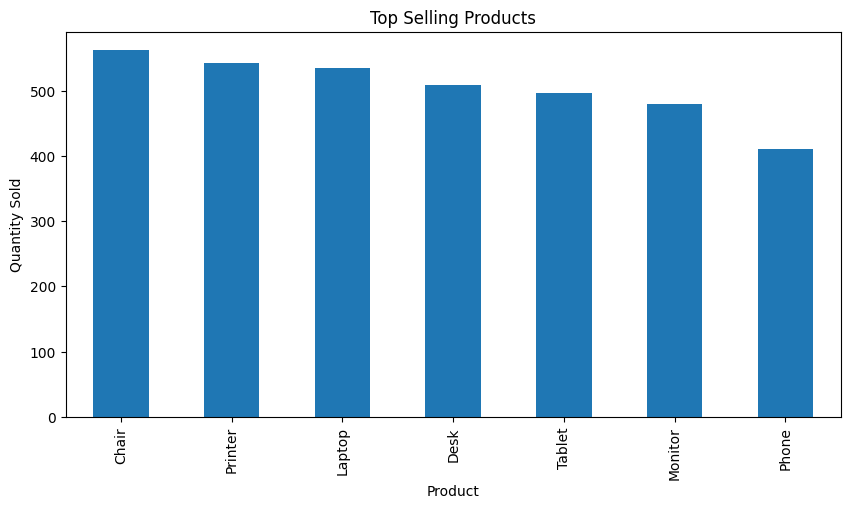

In [23]:
top_products = df.groupby(
    "Product"
)["Quantity"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

top_products.plot(
    kind="bar"
)

plt.title("Top Selling Products")

plt.ylabel("Quantity Sold")

plt.show()

## Referral Source Analysis

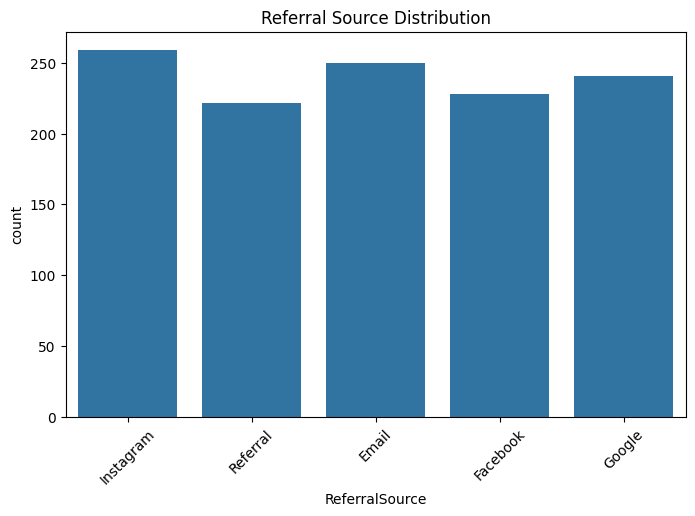

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="ReferralSource",
    data=df
)

plt.title("Referral Source Distribution")

plt.xticks(rotation=45)

plt.show()

## Final Dataset Information

In [25]:
print("Final Dataset Shape:")
print(df.shape)

print("\nFinal Columns:")
print(df.columns)

Final Dataset Shape:
(1200, 18)

Final Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'OrderMonth', 'OrderYear', 'AvgItemCost', 'DiscountApplied'],
      dtype='object')


## Save Clean Dataset

In [26]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


## Project Summary

### The dataset contained missing values only in the CouponCode column, which is categorical in nature. Therefore, categorical imputation using "No_Coupon" was applied. Mean, Median, and KNN imputation techniques were not applicable because no numerical features contained missing values.
